# Test run of BP

In [1]:
from sim_pipeline import *
from plot_helpers import *

import numpy as np

## Simulation

## STATIC SENSOR SELECTION

In [4]:

def static_bp_sim_pipeline(param_list, Nsim, T_max, N, d, results_df, method, kind="rrg"):
    for delta, lam, rho in tqdm(param_list, desc="Simulations"):
        for sim in range(Nsim):
            # check if results already exist for this combination of parameters
            if ((results_df["delta"] == delta) & (results_df["lambda"] == lam) & (results_df["rho"] == rho) & (results_df["method"] == method) & (results_df["sim"] == sim)).sum() == Nsim:
                continue

            # 1) Generate dynamic process simulation
            G, contacts, s0 = gen_graph_sim(N, d, lam=lam, T_max=T_max, delta=delta, kind=kind)
            status_nodes = simulate_SI(G, s0, lam, T_max)

            # 2) Generate sensor observations (random and selected)
            obs_selected = gen_selected_sensor_obs(G, rho, status_nodes, method=method)

            # 3) Inference with BP for both random and selected sensors
            bp_fg_rnd = fg.FactorGraph(N,T_max,contacts,[],delta) # for x_rnd: BP with no obs
            bp_fg_rnd.update(maxit=10, print_iter=None)
            marg_rnd = bp_fg_rnd.marginals()
            Mt_rnd = get_Mt(marg_rnd, t=0)
            x_rnd = np.argmax(Mt_rnd, axis=0)

            bp_fg_selected = fg.FactorGraph(N,T_max,contacts,obs_selected,delta)
            it_selected, _ = bp_fg_selected.update(maxit=10, print_iter=None)
            marg_selected = bp_fg_selected.marginals()

            # 4) Compute performance metrics:
            measures_selected, x_est_selected = compute_measures(marg_selected, s0, delta, status_nodes, x_rnd, Mt_rnd=Mt_rnd)
            rank_selected = compute_rank(marg_selected, s0)
            precision_selected, recall_selected = compute_precision_recall(x_est_selected, s0)
            f1_selected = compute_f1(precision_selected, recall_selected)

            # 5) Store results in results df
            results_df.loc[len(results_df)] = [
                method, kind, rho, delta, lam, sim, measures_selected["Ov"], measures_selected["MO"], measures_selected["Ov_tilde"], measures_selected["MO_tilde"], 
                measures_selected["SE"], measures_selected["MSE"], rank_selected, precision_selected, recall_selected, f1_selected
                ]


In [5]:
# sim parameters
lambdas=[0.3]
T_max = 10
N=50
deltas= [0.3]
rho_list = np.arange(0, 1.1, 0.1)
Nsim = 5
d=3
param_list = [(delta, lam, rho) for delta in deltas for lam in lambdas for rho in rho_list]
# sensor selection method
methods = ["page_rank"] #, "betweenness"] #, "degree", "eigenvector", "katz", "page_rank"

results_df = pd.DataFrame(columns=["sensor_type", "rho", "delta", "lambda", "O", "O_tilde", "rank", "precision", "recall", "f1", "SE", "MSE", "sim"])

#for method in methods:
    #bp_sim_pipeline(param_list, Nsim, T_max, N, d, results_df, method, with_random=True)
results_df = pd.DataFrame(columns=["method", "graph", "rho", "delta", "lambda", "sim", "O", "MO", "O_tilde", "MO_tilde", "SE", "MSE", "rank", "precision", "recall", "f1"])

method = "random"
static_bp_sim_pipeline(param_list, Nsim, T_max, N, d, results_df, method, kind="rrg")


Simulations:  73%|███████▎  | 8/11 [00:05<00:01,  1.54it/s]


KeyboardInterrupt: 

In [47]:
random_results = results_df[results_df["sensor_type"] == "random"]
pagerank_results = results_df[results_df["sensor_type"] == "page_rank"]
#betweenness_results = results_df[results_df["sensor_type"] == "betweenness"]

In [48]:
# save results_df to results dir, with name describing the params
results_df.to_csv("./results/res_dyn.d01_03.csv", index=False)

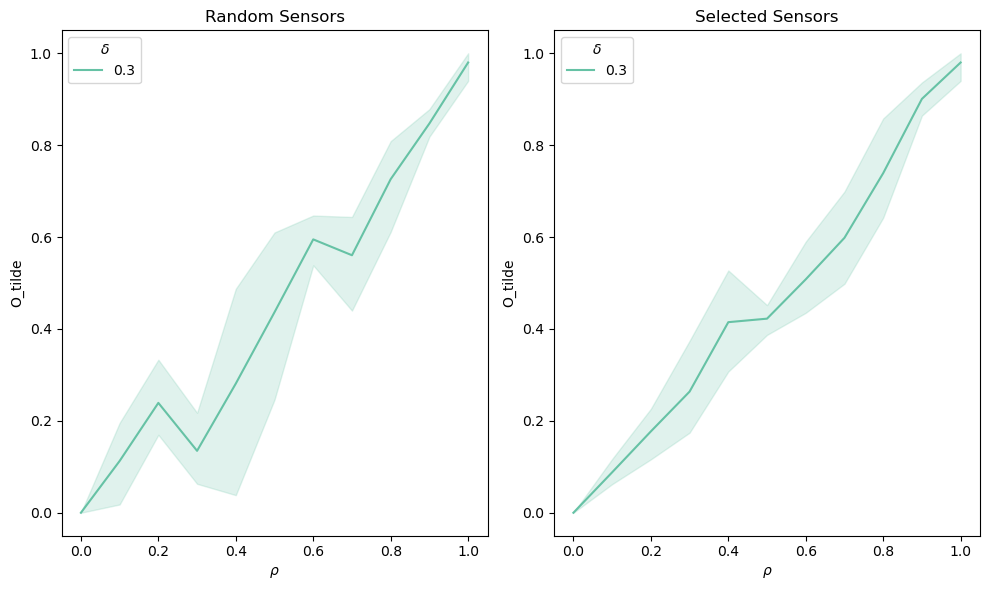

In [49]:
plot_side_by_side(random_results, pagerank_results, metric="O_tilde")

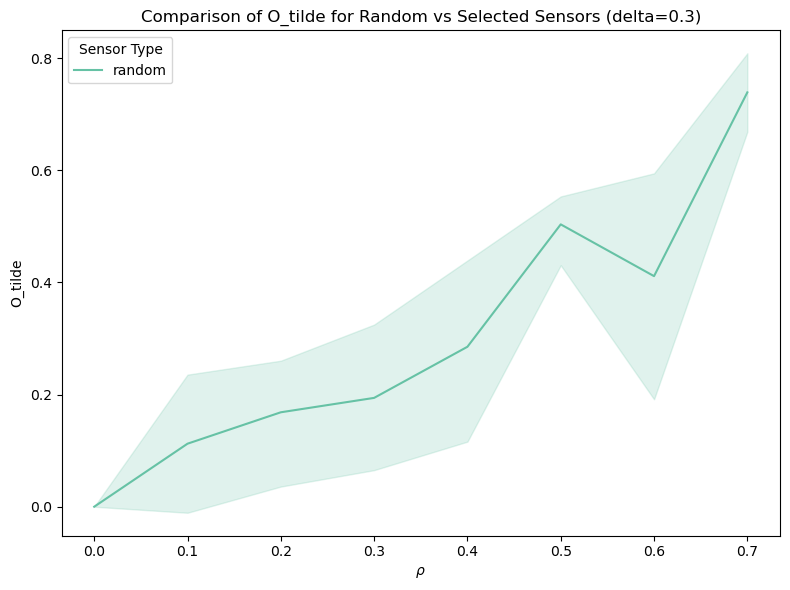

In [7]:
plot_comparison(results_df, delta=0.3, metric="O_tilde")

In [208]:
def bp_sim_pipeline_dyn(param_list, Nsim, T_max, N, d, results_df, method):
    for delta, lam, rho in tqdm(param_list, desc="Simulations"):
        for sim in range(Nsim):
            # check if results already exist for this combination of parameters
            if ((results_df["delta"] == delta) & (results_df["lambda"] == lam) & (results_df["rho"] == rho) & (results_df["sensor_type"] == method)).sum() == Nsim:
                continue

            # 1) Generate dynamic process simulation
            G, contacts, s0 = gen_graph_sim(N, d, lam=lam, T_max=T_max, delta=delta)
            status_nodes = simulate_SI(G, s0, lam, T_max)

            # 2) Generate sensor observations (random and selected)
            initial_obs = gen_sensor_obs(rho/2, status_nodes)

            # 3) Inference with BP for both random and selected sensors
            bp_fg_dyn = fg.FactorGraph(N,T_max,contacts,[],delta)
            rho_max = rho
            #run_bp_dynamic(bp_fg_dyn, initial_obs, rho_max=rho_max, N=N, status_nodes=status_nodes, max_iter=5)
            #bp_fg_final, final_obs = run_bp_dynamic_resets2(initial_obs, rho_max, N, T_max, contacts, delta, status_nodes, max_iter=10, tol=1e-6, damp=0.5, k_frac=0.3))
            #bp_fg_final, final_obs = run_bp_greedy_cheat(initial_obs, rho_max, N, T_max, contacts, delta, status_nodes, s0, max_iter=200, tol=1e-6, damp=0.5)
            marg = bp_fg_final.marginals()

            bp_fg_rnd = fg.FactorGraph(N,T_max,contacts,[],delta) # for x_rnd: BP with no obs
            marg_rnd = bp_fg_rnd.marginals()
            Mt_rnd = get_Mt(marg_rnd, t=0)
            x_rnd = np.argmax(Mt_rnd, axis=0)

            # 4) Compute performance metrics:
            # Ov_random = compute_overlap_t0(marg, s0)
            # Ov_selected = compute_overlap_t0(marg_selected, s0)
            # Otilde_random = compute_O_tilde(Ov_random, s0, delta)
            # Otilde_selected = compute_O_tilde(Ov_selected, s0, delta)
            # xpred_random = compute_xest_t0(marg)
            # xpred_selected = compute_xest_t0(marg_selected)
            measures_dyn, x_est_dyn = compute_measures(marg, s0, delta, status_nodes, x_rnd)
            rank_random = compute_rank(marg, s0)
            precision_dyn, recall_dyn = compute_precision_recall(x_est_dyn, s0)
            f1_dyn= compute_f1(precision_dyn, recall_dyn) 

            # 5) Store results in results df
            results_df.loc[len(results_df)] = [method, rho, delta, lam, measures_dyn["Ov"], measures_dyn["Ov_tilde"], rank_random, precision_dyn, recall_dyn, f1_dyn, measures_dyn["SE"], measures_dyn["MSE"]]


In [210]:
def min_dist_to_selected(i, selected, G):
    if len(selected) == 0:
        return 1
    return min(nx.shortest_path_length(G, i, j) for j in selected)

In [211]:
def node_entropy(marg):
    # marg: (N, T+2)
    marg = marg / marg.sum(axis=1, keepdims=True)
    eps = 1e-12
    return -np.sum(marg * np.log(marg + eps), axis=1)


def run_bp_entropy(initial_obs, G, rho_max, N, T, contacts, delta, status_nodes,
                   max_iter=200, tol=1e-6, damp=0.5, gt=None, beta0=5.0, new=False):

    initial_obs = np.array(initial_obs)

    if initial_obs.size == 0:
        already_selected = set()
        current_obs = np.empty((0, 3), dtype=int)
    else:
        already_selected = set(initial_obs[:, 0].astype(int))
        current_obs = initial_obs.copy()

    # initial BP
    bp_fg = fg.FactorGraph(N, T, contacts, current_obs, delta)
    bp_fg.update(maxit=max_iter, tol=tol, damp=damp)

    target_n = int(rho_max * N)
    selected_nodes_history = []
    ov_history = []

    while len(already_selected) < target_n:
        if len(already_selected) >= N:
            break
        beta = beta0 + 5 * len(already_selected) / N
        #beta = beta + 5 * len(already_selected) / N
        if not new:
            # --- compute marginals ---
            marg = bp_fg.marginals()  # (N, T+2)

            # --- entropy per node ---
            H = node_entropy(marg)

            # --- candidate nodes ---
            candidates = [v for v in range(N) if v not in already_selected]
            H_cand = H[candidates]

            # --- softmax sampling ---
            probs = np.exp(beta * H_cand)
            probs = probs / np.sum(probs)

            best_node = np.random.choice(candidates, p=probs)
        else:
            # --- compute marginals ---
            marg = bp_fg.marginals()

            Mt = get_Mt(marg, t=0)
            p_inf = Mt[1]

            # --- uncertainties ---
            unc = p_inf * (1 - p_inf)          # (N,)
            H = node_entropy(marg)             # (N,)
            A = nx.to_numpy_array(G)           # (N, N)
            # --- influence (1-hop) ---
            influence = A @ unc                # (N,)

            # --- candidate nodes ---
            candidates = [v for v in range(N) if v not in already_selected]

            # --- diversity (cheap version) ---
            div = np.ones(len(candidates))
            if len(already_selected) > 0:
                selected_mask = np.zeros(N)
                selected_mask[list(already_selected)] = 1
                div = 1 + (A @ (1 - selected_mask))[candidates]

            # --- final score ---
            scores = (H * influence)[candidates] * div

            # --- softmax sampling ---
            scores = scores - np.max(scores)
            probs = np.exp(beta * scores)
            probs /= probs.sum()

            best_node = np.random.choice(candidates, p=probs)
            # marg = bp_fg.marginals()  # (N, T+2)
            # H = node_entropy(marg)

            # # --- candidate nodes ---
            # candidates = [v for v in range(N) if v not in already_selected]
            # Mt = get_Mt(marg, t=0)
            # p_inf = Mt[1]

            # H = node_entropy(marg)

            # scores = []
            # for i in candidates:
            #     disagreement = np.sum(np.abs(p_inf[i] - p_inf))
            #     diversity = min_dist_to_selected(i, already_selected, G)
            #     scores.append(H[i] * disagreement * diversity)

            # scores = np.array(scores)

            # probs = np.exp(beta * scores)
            # probs /= probs.sum()

            # best_node = np.random.choice(candidates, p=probs)

        # --- add full trajectory observation ---
        new_rows = [
            (best_node, int(status_nodes[t, best_node]), t)
            for t in range(status_nodes.shape[0])
        ]

        already_selected.add(best_node)
        current_obs = np.vstack([current_obs, np.array(new_rows, dtype=int)])
        selected_nodes_history.append(best_node)

        # --- evaluate performance (optional) ---
        if gt is not None:
            Mt = get_Mt(marg, t=0)
            x_est = np.argmax(Mt, axis=0)
            ov = OV(x_est, gt)
            ov_history.append(ov)
            print(f"selected {best_node}, OV={ov:.4f}, rho={len(already_selected)/N:.3f}")
        else:
            Mt = get_Mt(marg, t=0)
            mo = MOV(Mt)
            print(f"selected {best_node}, MO={mo:.4f}, rho={len(already_selected)/N:.3f}")

        # --- update BP ---
        bp_fg = fg.FactorGraph(N, T, contacts, current_obs, delta)
        bp_fg.update(maxit=max_iter, tol=tol, damp=damp)

    return bp_fg, current_obs, selected_nodes_history, ov_history

In [213]:
#bp_sim_pipeline_dyn(param_list, Nsim, T_max, N, d, results_df, "dyn_resets_greedy")
sensors_df = pd.DataFrame(columns=["sim", "betweeness", "pagerank", "mean_dist_from_prev", "ov_gain"])
bp_sim_pipeline_dyn(param_list, Nsim, T_max, N, d, results_df, "dyn_resets_greedy_MOV", rho_list, sensors_df)

Simulations:   0%|          | 0/11 [00:00<?, ?it/s]

selected 46, MO=0.7124, rho=0.020
selected 10, MO=0.7280, rho=0.040
selected 7, MO=0.7402, rho=0.060
selected 17, MO=0.7522, rho=0.080
selected 26, MO=0.7642, rho=0.100
selected 3, MO=0.7762, rho=0.120
selected 28, MO=0.7882, rho=0.140
selected 44, MO=0.7969, rho=0.160
selected 42, MO=0.8048, rho=0.180
selected 11, MO=0.8126, rho=0.200
selected 6, MO=0.8191, rho=0.220
selected 33, MO=0.8259, rho=0.240
selected 40, MO=0.8323, rho=0.260
selected 38, MO=0.8408, rho=0.280
selected 31, MO=0.8472, rho=0.300
selected 24, MO=0.8532, rho=0.320
selected 18, MO=0.8592, rho=0.340
selected 25, MO=0.8652, rho=0.360
selected 27, MO=0.8712, rho=0.380
selected 41, MO=0.8772, rho=0.400
selected 49, MO=0.8831, rho=0.420
selected 48, MO=0.8891, rho=0.440
selected 20, MO=0.8951, rho=0.460
selected 39, MO=0.9011, rho=0.480
selected 9, MO=0.9069, rho=0.500
selected 45, MO=0.9132, rho=0.520
selected 32, MO=0.9185, rho=0.540
selected 22, MO=0.9234, rho=0.560
selected 19, MO=0.9288, rho=0.580
selected 29, MO=0.

Simulations: 100%|██████████| 11/11 [08:44<00:00, 47.69s/it]  


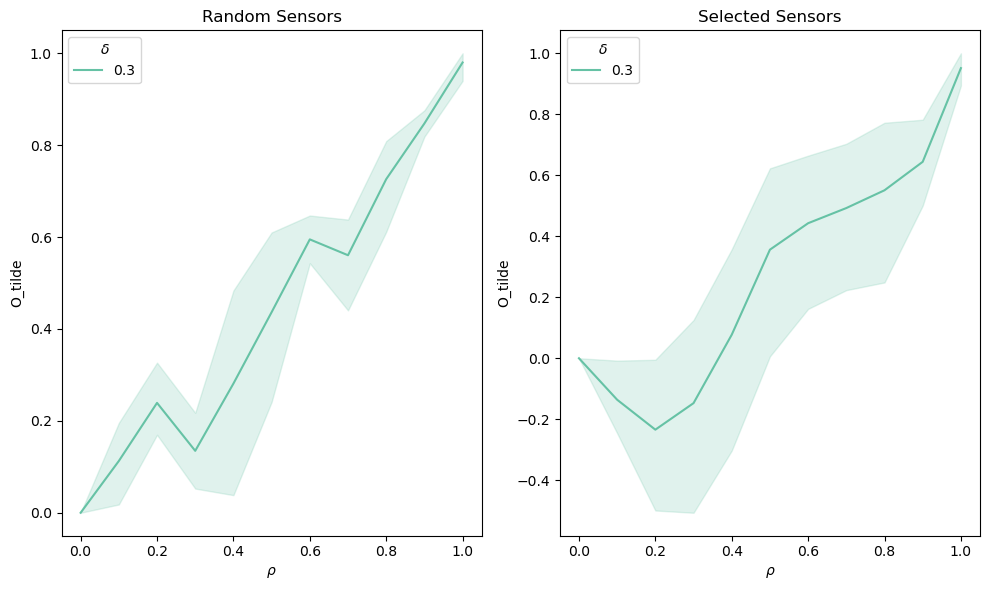

In [214]:
pagerank_results = results_df[results_df["sensor_type"] == "dyn_resets_greedy_MOV"]
plot_side_by_side(random_results, pagerank_results, metric="O_tilde")

In [215]:
# remove: page_rank, dyn_resets_entropy, dyn_resets_entropy05
results_df_filtered = results_df[~results_df["sensor_type"].isin(["page_rank", "dyn_resets_entropy", "dyn_resets_entropy2",
                                                                  "dyn_resets_entropy05", "dyn_resets_greedy_gt2", "dyn_resets_entropy_newer", "dyn_resets_entropy_new_schedule"])]

In [216]:
set(results_df_filtered.sensor_type.values)

{'dyn_resets_entropy_new',
 'dyn_resets_entropy_scheduler',
 'dyn_resets_greedy_MOV',
 'dyn_resets_greedy_gt',
 'dyn_resets_mod_entropy',
 'dyn_resets_modd_entropy',
 'random'}

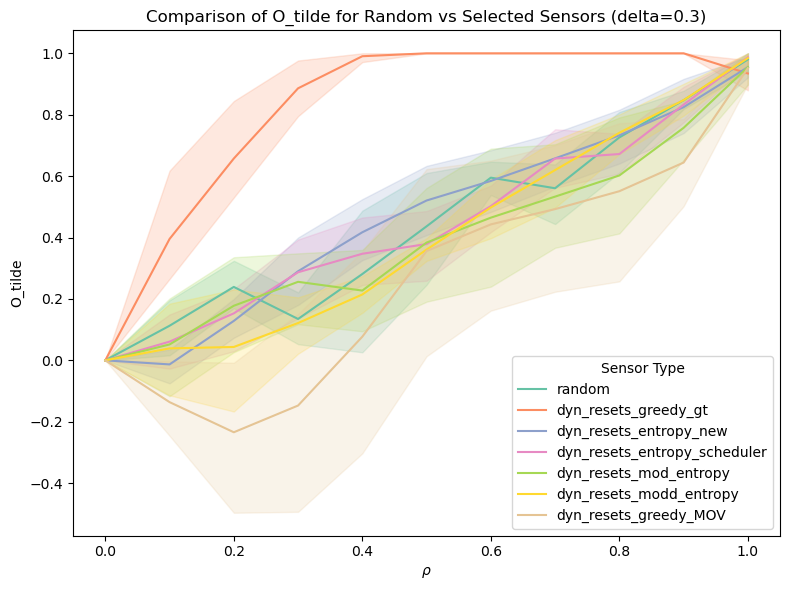

In [217]:
plot_comparison(results_df_filtered, delta=0.3, metric="O_tilde")